In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/gurgaon_properties_cleaned_v2.csv")

In [ ]:
df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,...,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,dlf the magnolias,Sector 42,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up...,4,4,3+,14,...,5400.0,1,1,0,1,1,Furnished,1,28.454042,77.098740
1,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8,...,NaN,1,1,0,1,1,Unknown,5,28.508181,76.986806
2,experion windchants,Sector 112,6.25,16609.0,3763,Super Built-up area 3763(349.59 sq.m.)Built-up...,3,5,3,6,...,NaN,0,1,0,0,0,Semi-Furnished,0,28.518719,77.014458
3,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet a...,3,3,3,11,...,1141.0,0,1,0,0,0,Unknown,0,28.359337,76.969227
4,dlf new town heights 1,Sector 90,2.85,10451.0,2727,Super Built-up area 2727(253.35 sq.m.)Built-up...,4,4,3+,4,...,2721.0,0,1,0,1,0,Semi-Furnished,21,28.403442,76.930775


In [ ]:
df.shape

(1563, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   society              1563 non-null   object 
 1   sector               1563 non-null   object 
 2   price                1563 non-null   float64
 3   price_per_sqft       1563 non-null   float64
 4   area                 1563 non-null   int64  
 5   areaWithType         1563 non-null   object 
 6   bedRoom              1563 non-null   int64  
 7   bathroom             1563 non-null   int64  
 8   balcony              1563 non-null   object 
 9   floorNum             1563 non-null   object 
 10  facing               1563 non-null   object 
 11  agePossession        1563 non-null   object 
 12  super_built_up_area  1343 non-null   float64
 13  built_up_area        505 non-null    float64
 14  carpet_area          1025 non-null   float64
 15  study room           1563 non-null   i

In [ ]:
df.duplicated().sum()

np.int64(0)

# 1. society

In [ ]:
df['society'].value_counts().shape

(313,)

In [ ]:
df['society'].value_counts()

,count
society,
godrej air,50
hero homes,42
godrej meridien,39
sobha city,32
dlf new town heights 1,27
...,...
signature global city 63a,1
technocrat society,1
suncity avenue 76,1


In [ ]:
df['society'].value_counts(normalize=True).cumsum().head(75)

,proportion
society,
godrej air,0.031990
hero homes,0.058861
godrej meridien,0.083813
sobha city,0.104287
dlf new town heights 1,0.121561
...,...
alpha corp gurgaonone 84,0.641715
mahindra aura,0.645553
chintels serenity,0.649392


In [ ]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>50)": (society_counts >= 50).sum(),
    "High (25-49)": ((society_counts >= 25) & (society_counts <= 49)).sum(),
    "Average (10-24)": ((society_counts >= 10) & (society_counts < 25)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>50)': np.int64(1),
 'High (25-49)': np.int64(4),
 'Average (10-24)': np.int64(42),
 'Low (2-9)': np.int64(151),
 'Very Low (1)': np.int64(115)}

<Axes: xlabel='society'>

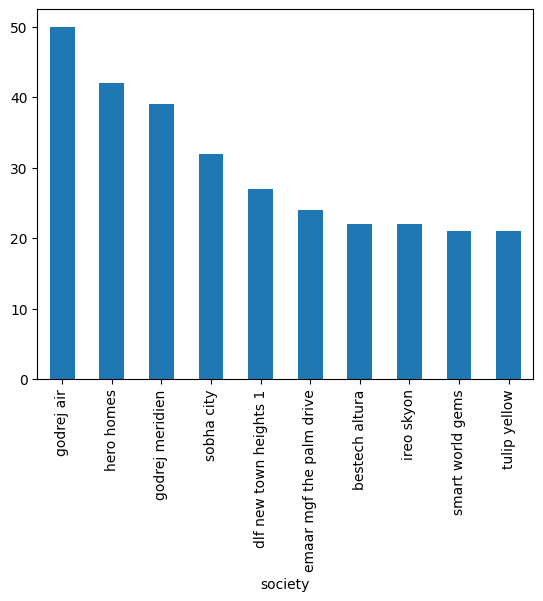

In [ ]:
df['society'].value_counts().head(10).plot(kind='bar')

In [ ]:
df['society'].isnull().sum()

np.int64(0)

# Observations
 * There are 331 societies.
 * The top 75 societies have 45 percent of the preperties and the rest 65      percent of the properties come under the remaining 331 societies
 * Very High (>=50): Only 1 society has more or eqaul to 50 listings.
 * High (25-49): 4 societies have between 25 to 49 listings.
 * Average (10-25): 42 societies fall in this range with 10 to 25 listings each.
 * Low (2-9): 151 societies have between 2 to 9 listings.
 * Very Low (1): A significant number, 115 societies, have only 1 listing.

# sector

In [ ]:
df['sector'].value_counts().shape

(96,)

<Axes: xlabel='sector'>

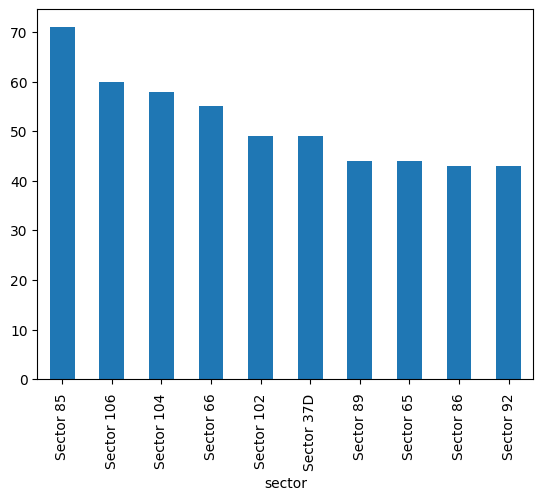

In [ ]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [ ]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

# Frequency distribution for societies
sector_frequency_bins = {
    "Very High (>50)": (sector_counts >= 50).sum(),
    "High (25-49)": ((sector_counts >= 25) & (sector_counts <= 49)).sum(),
    "Average (10-24)": ((sector_counts >= 10) & (sector_counts < 25)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}
sector_frequency_bins

{'Very High (>50)': np.int64(4),
 'High (25-49)': np.int64(20),
 'Average (10-24)': np.int64(29),
 'Low (2-9)': np.int64(29),
 'Very Low (1)': np.int64(14)}

# Observations
 * There are 96 sectors.
 * Frequency distribution of sectors:
  * Very High (>=50): Only 4 sectors has more or eqaul to 50 listings.
  * High (25-49): 20 sectors have between 25 to 49 listings.
  * Average (10-24): 29 sectors fall in this range with 10 to 24 listings each.
  * Low (2-9): 29 sectors have between 2 to 9 listings.
  * Very Low (1): A significant number, 14 sectors, have only 1 listing.

# Price

In [ ]:
df['price'].isnull().sum()

np.int64(0)

In [ ]:
df['price'].describe()

,price
count,1563.000000
mean,4.007287
std,5.787071
min,0.430000
25%,2.050000
50%,2.750000
75%,4.010000
max,85.000000


<Axes: xlabel='price', ylabel='Count'>

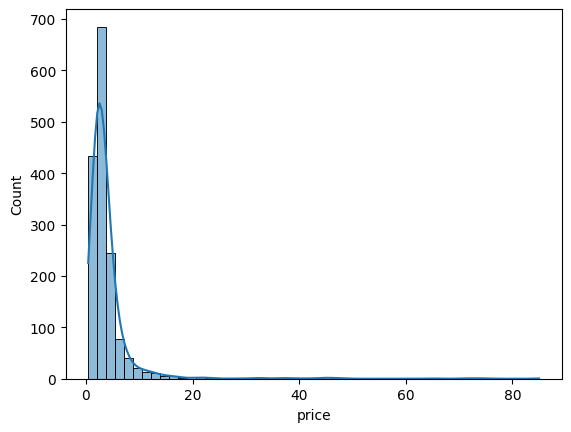

In [ ]:
sns.histplot(df['price'], kde=True, bins=50)

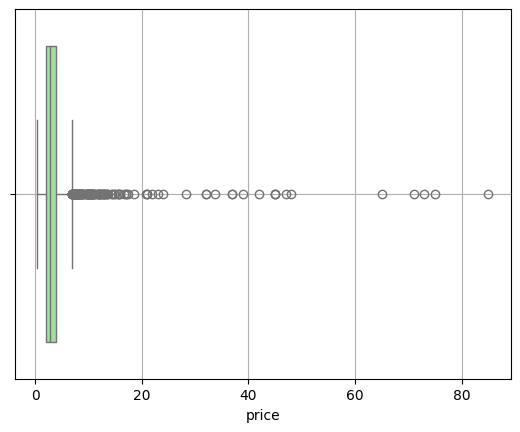

In [ ]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

# Descriptive Statistics:

*  Count: There are no missing price entries.
*  Mean Price: The average price is approximately 4 crores.
*  Median Price: The median (or 50th percentile) price is 2.75 crores.
*  Standard Deviation: The prices have a standard deviation of 5.78, indicating variability in the prices.
*  Range: Prices range from a minimum of 0.43 crores to a maximum of 85 crores.
*  IQR: The interquartile range (difference between 75th and 25th percentile) is from 2.05 crores to 4.01 crores.

# Visualizations:

*  Distribution: The histogram indicates that most properties are priced in the lower range (below 25 crores), with a few properties going beyond 20 crores.
*  Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 25 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
*  Missing Values: There are 0 missing values in the price column.

In [ ]:
# skewness or kurtosis
df['price'].skew()

np.float64(8.079721562754141)

In [ ]:
df['price'].kurt()

np.float64(83.02709138876004)

 **Skewness**: The price distribution has a skewness of approximately 8.07, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 83.02. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [ ]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

,price
0.01,0.6386
0.05,1.3200
0.95,9.5000
0.99,32.0000


# Quantile Analysis:

*  1% Quantile: Only 1% of properties are priced below 0.63 crores.
*  5% Quantile: 5% of properties are priced below 1.32 crores.
*  95% Quantile: 95% of properties are priced below 9.5 crores.
*  99% Quantile: 99% of properties are priced below 32 crores, indicating that very few properties are priced above this value.



In [ ]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.96)

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound,upper_bound)

-0.8900000000000001 6.949999999999999


In [ ]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

outliers.shape

(134, 24)

In [ ]:
outliers['price'].describe()

,price
count,134.000000
mean,15.833806
std,14.888370
min,6.950000
25%,7.912500
50%,10.320000
75%,14.950000
max,85.000000


# Outliers Analysis (using IQR method):

*  Based on the IQR method, there are 134 properties considered as outliers.
*  These outliers have an average price of approximately 15.8 crores.
*  The range for these outliers is from 6.95 crores to 85 crores.

<Axes: xlabel='price'>

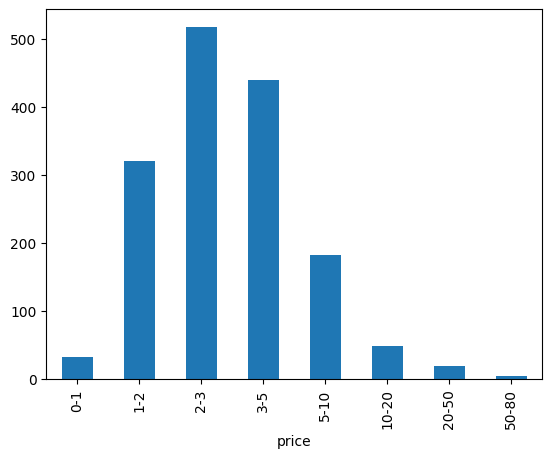

In [ ]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50, 80]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50", "50-80"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

* The majority of properties are priced in the "1-2 crores" and "3-5 crores" ranges.
 * There's a significant drop in the number of properties priced above "10 crores."

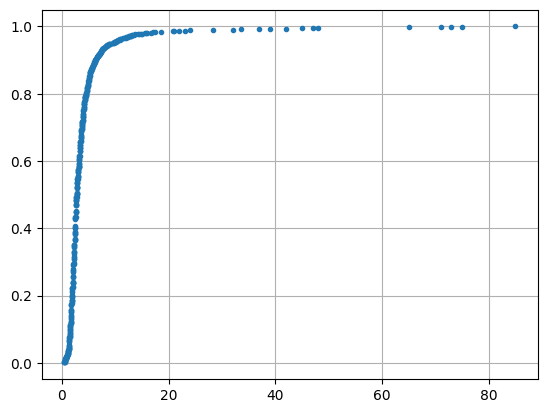

In [ ]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker = '.', linestyle='none')
plt.grid()

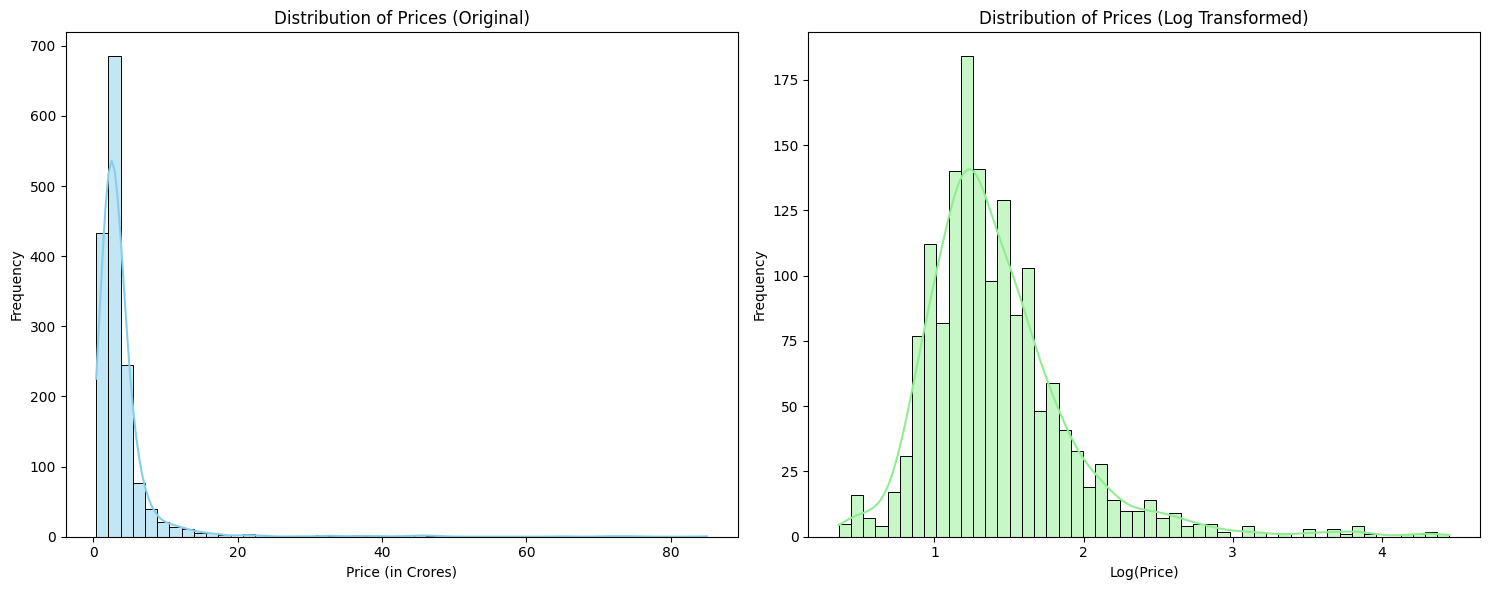

In [ ]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**np.log1p(x)**: This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [ ]:
print(np.log1p(df['price']).skew())
print(np.log1p(df['price']).kurt())

1.8364268416143132
6.27440239405833


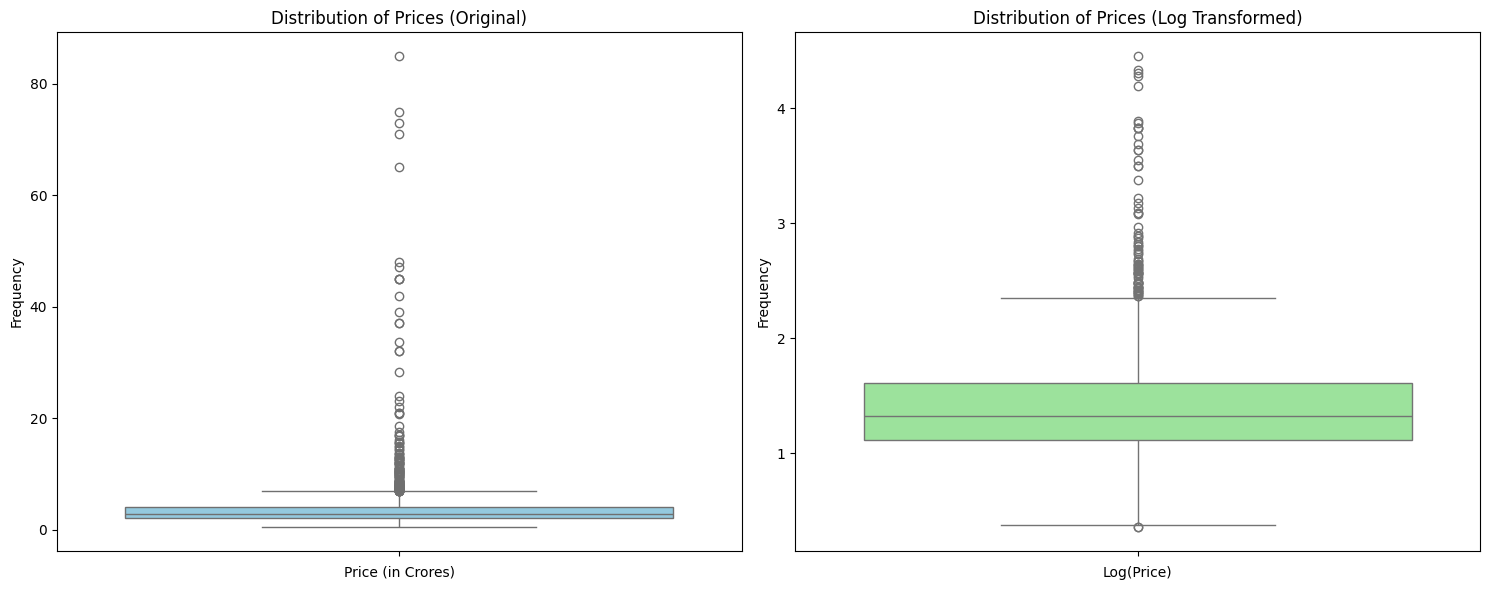

In [ ]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
df[df['price'] > 60]

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,...,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
253,dlf the camellias,DLF Golf Course,73.0,98649.0,7400,Super Built-up area 7400(687.48 sq.m.)Carpet a...,4,8,3+,7,...,6000.0,1,1,1,1,0,Furnished,0,28.451320,77.100660
267,dlf the camellias,Sector 42,71.0,91026.0,7800,Super Built-up area 7800(724.64 sq.m.) sqft,3,4,3,1,...,NaN,1,1,1,1,0,Furnished,21,28.451180,77.099913
587,dlf the camellias,Sector 42,65.0,87838.0,7400,Super Built-up area 7400(687.48 sq.m.)Carpet a...,4,8,3+,8,...,5500.0,1,1,1,1,0,Furnished,24,28.451320,77.100660
887,dlf the camellias,DLF Golf Course,75.0,101351.0,7400,Super Built-up area 7400(687.48 sq.m.)Carpet a...,4,8,3+,10,...,6000.0,1,1,1,1,0,Furnished,21,28.451320,77.100660
1054,dlf the magnolias,Sector 42,85.0,78704.0,10800,Carpet area: 10800 (1003.35 sq.m.) sqft,5,5,2,8,...,10800.0,1,1,0,0,1,Furnished,3,28.460428,77.103181


# price_per_sqft

In [ ]:
df['price_per_sqft'].isnull().sum()

np.int64(0)

In [ ]:
df['price_per_sqft'].describe()

,price_per_sqft
count,1563.000000
mean,17182.248880
std,18711.539371
min,6280.000000
25%,11686.500000
50%,14286.000000
75%,18369.500000
max,480000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

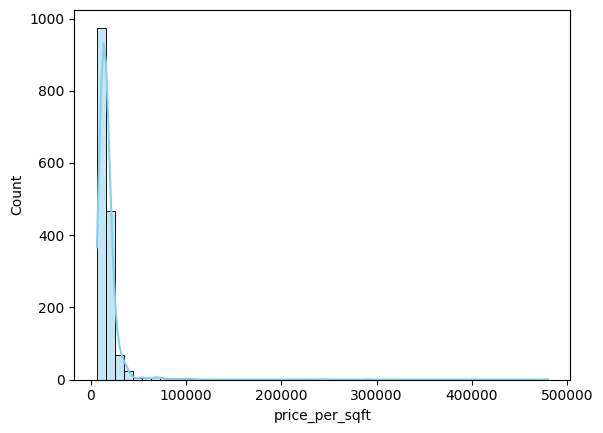

In [ ]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

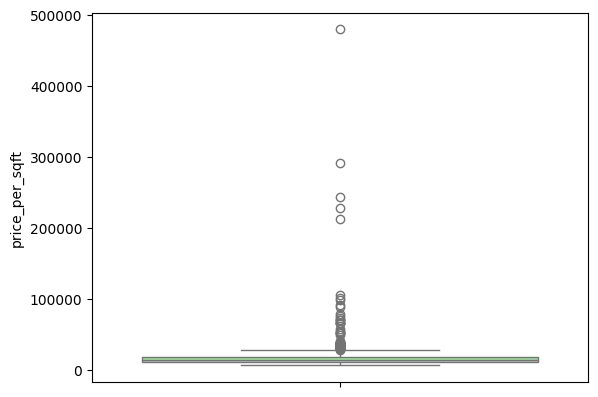

In [ ]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

**Observations**
*  Potential Outliers
*  Right Skewed

# bedRoom

In [ ]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

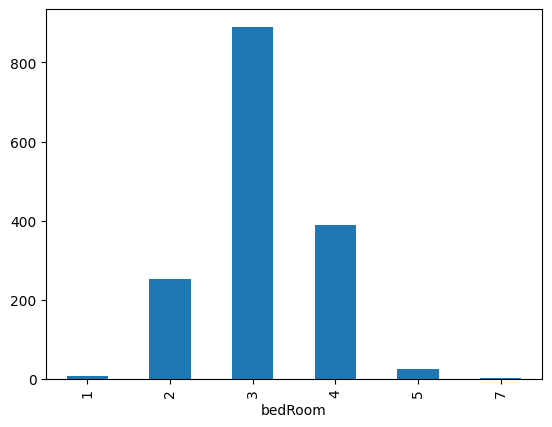

In [ ]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

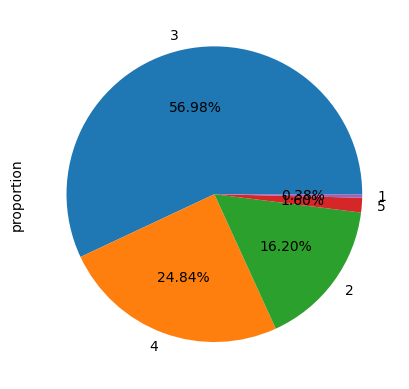

In [ ]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# bathroom

In [ ]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

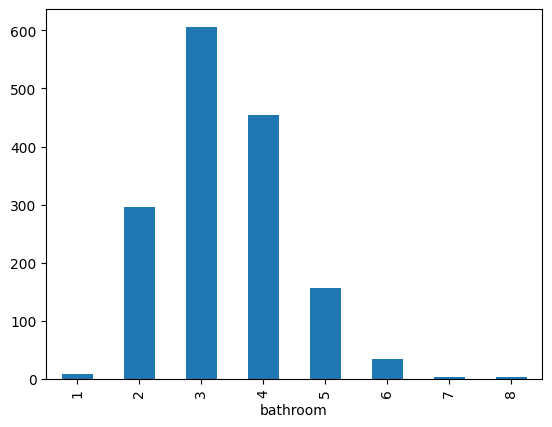

In [ ]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

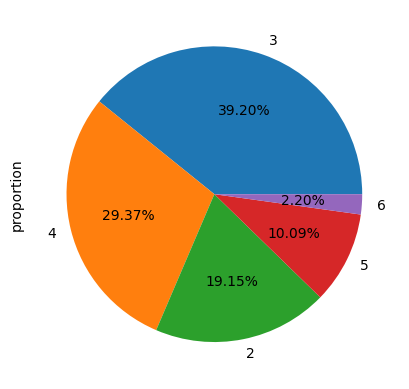

In [ ]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# balcony

In [ ]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

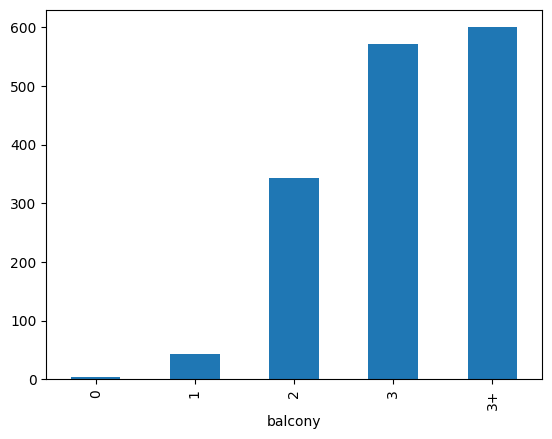

In [ ]:
df['balcony'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

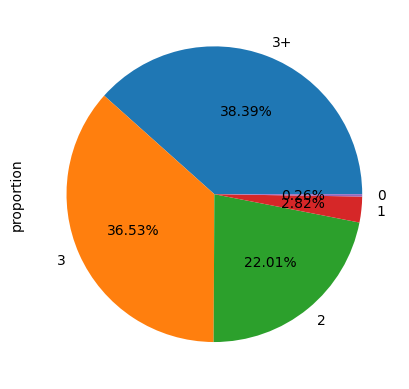

In [ ]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# floorNum

In [ ]:
df['floorNum'].isnull().sum()

np.int64(0)

In [ ]:
df = df.drop(index=509)

In [ ]:
df['floorNum'] = df['floorNum'].str.replace('G',"0")

In [ ]:
df['floorNum'] = df['floorNum'].astype('float')

In [ ]:
df['floorNum'].describe()

,floorNum
count,1562.000000
mean,10.263124
std,6.596490
min,0.000000
25%,6.000000
50%,9.000000
75%,14.000000
max,47.000000


<Axes: xlabel='floorNum'>

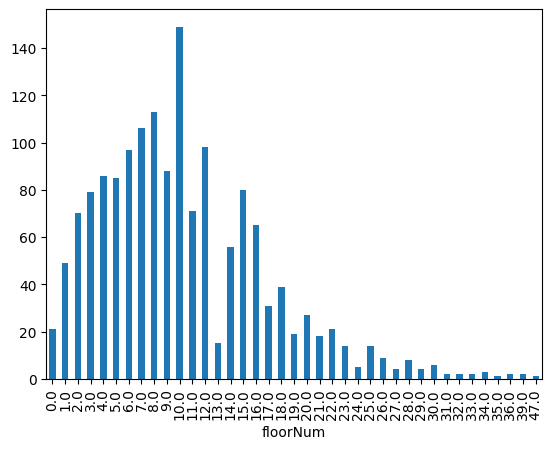

In [ ]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

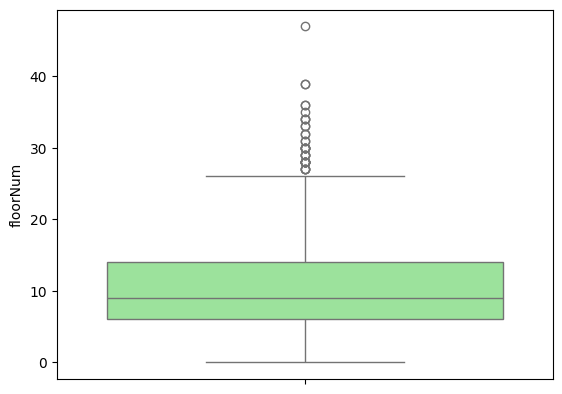

In [ ]:
sns.boxplot(df['floorNum'], color='lightgreen')

* The majority of the properties lie between the ground floor (0) and the 25th floor.
* Floors 1 to 4 are particularly common, with the 10rd floor being the most frequent.
* There are a few properties located at higher floors, but their frequency is much lower.
* The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 15th floors.
* Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

# facing

In [ ]:
df['facing'].isnull().sum()

np.int64(0)

In [ ]:
df['facing'].value_counts()

,count
facing,
East,514
North-East,474
North,275
West,138
North-West,61
South,49
South-East,32
South-West,19


# agePossesion

In [ ]:
df['agePossession'].isnull().sum()

np.int64(0)

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,688
New Property,377
Moderately Old,339
Old Property,106
Under Construction,47
Undefined,5


# areas

In [ ]:
# super_built_up_area

df['super_built_up_area'].isnull().sum()

np.int64(219)

In [ ]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1343.000000
mean,2183.447997
std,937.094988
min,476.000000
25%,1689.000000
50%,1975.000000
75%,2464.000000
max,11200.000000


<Axes: xlabel='super_built_up_area', ylabel='Count'>

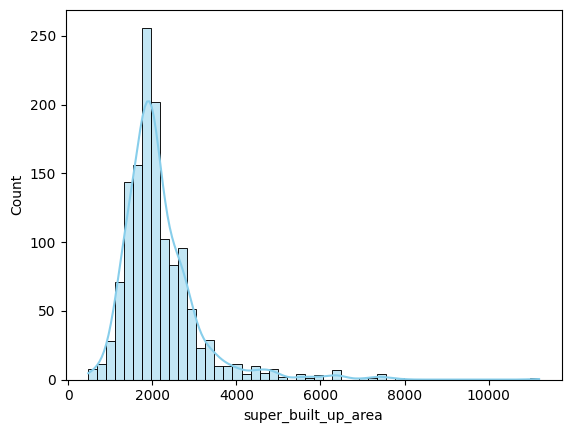

In [ ]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

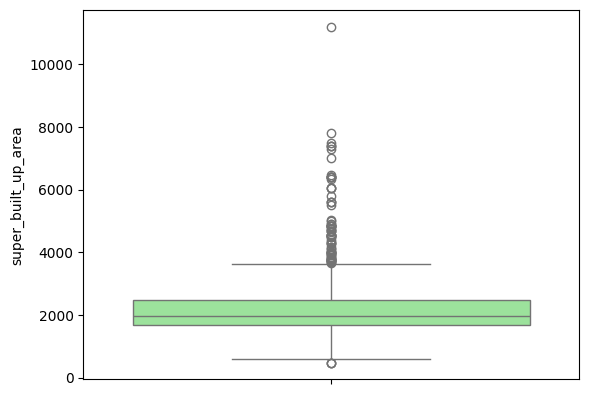

In [ ]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

* Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
* There are a few properties with a significantly larger area, leading to a right-skewed distribution.
* The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
* There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [ ]:
# built up area

df['built_up_area'].isnull().sum()

np.int64(1057)

In [ ]:
df['built_up_area'].describe()

,built_up_area
count,505.000000
mean,1968.602198
std,744.643249
min,739.000000
25%,1500.000000
50%,1850.000000
75%,2225.560000
max,6000.000000


<Axes: xlabel='built_up_area', ylabel='Count'>

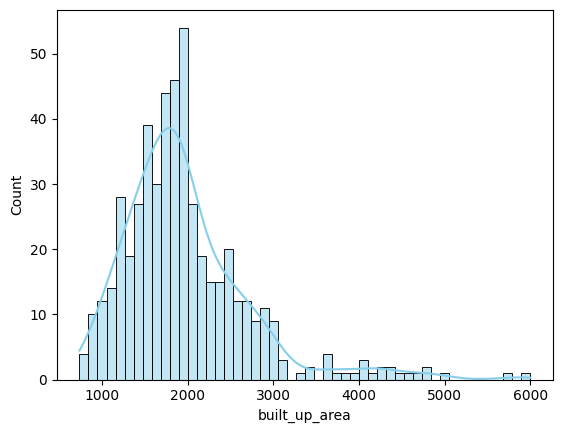

In [ ]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='built_up_area'>

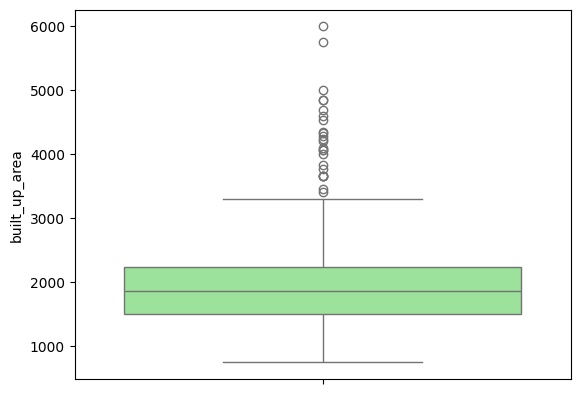

In [ ]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

In [ ]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(538)

In [ ]:
df['carpet_area'].describe()

,carpet_area
count,1024.000000
mean,1639.272310
std,854.123091
min,80.080000
25%,1155.000000
50%,1495.000000
75%,1900.250000
max,10800.000000


<Axes: xlabel='carpet_area', ylabel='Count'>

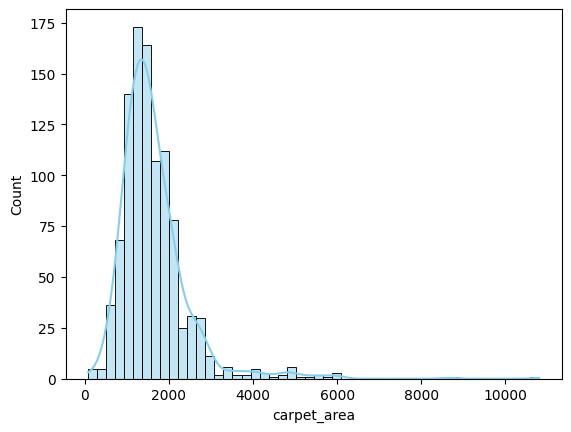

In [ ]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='carpet_area'>

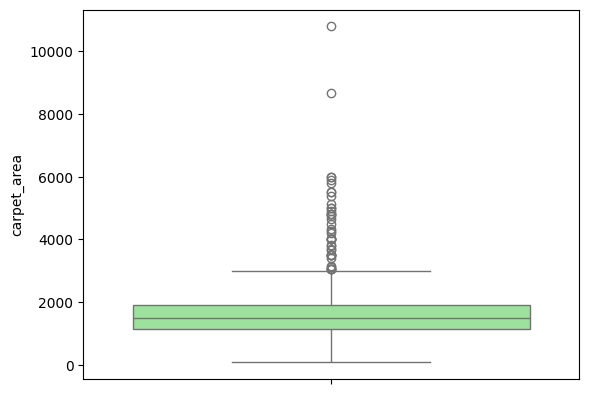

In [ ]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

# additional rooms

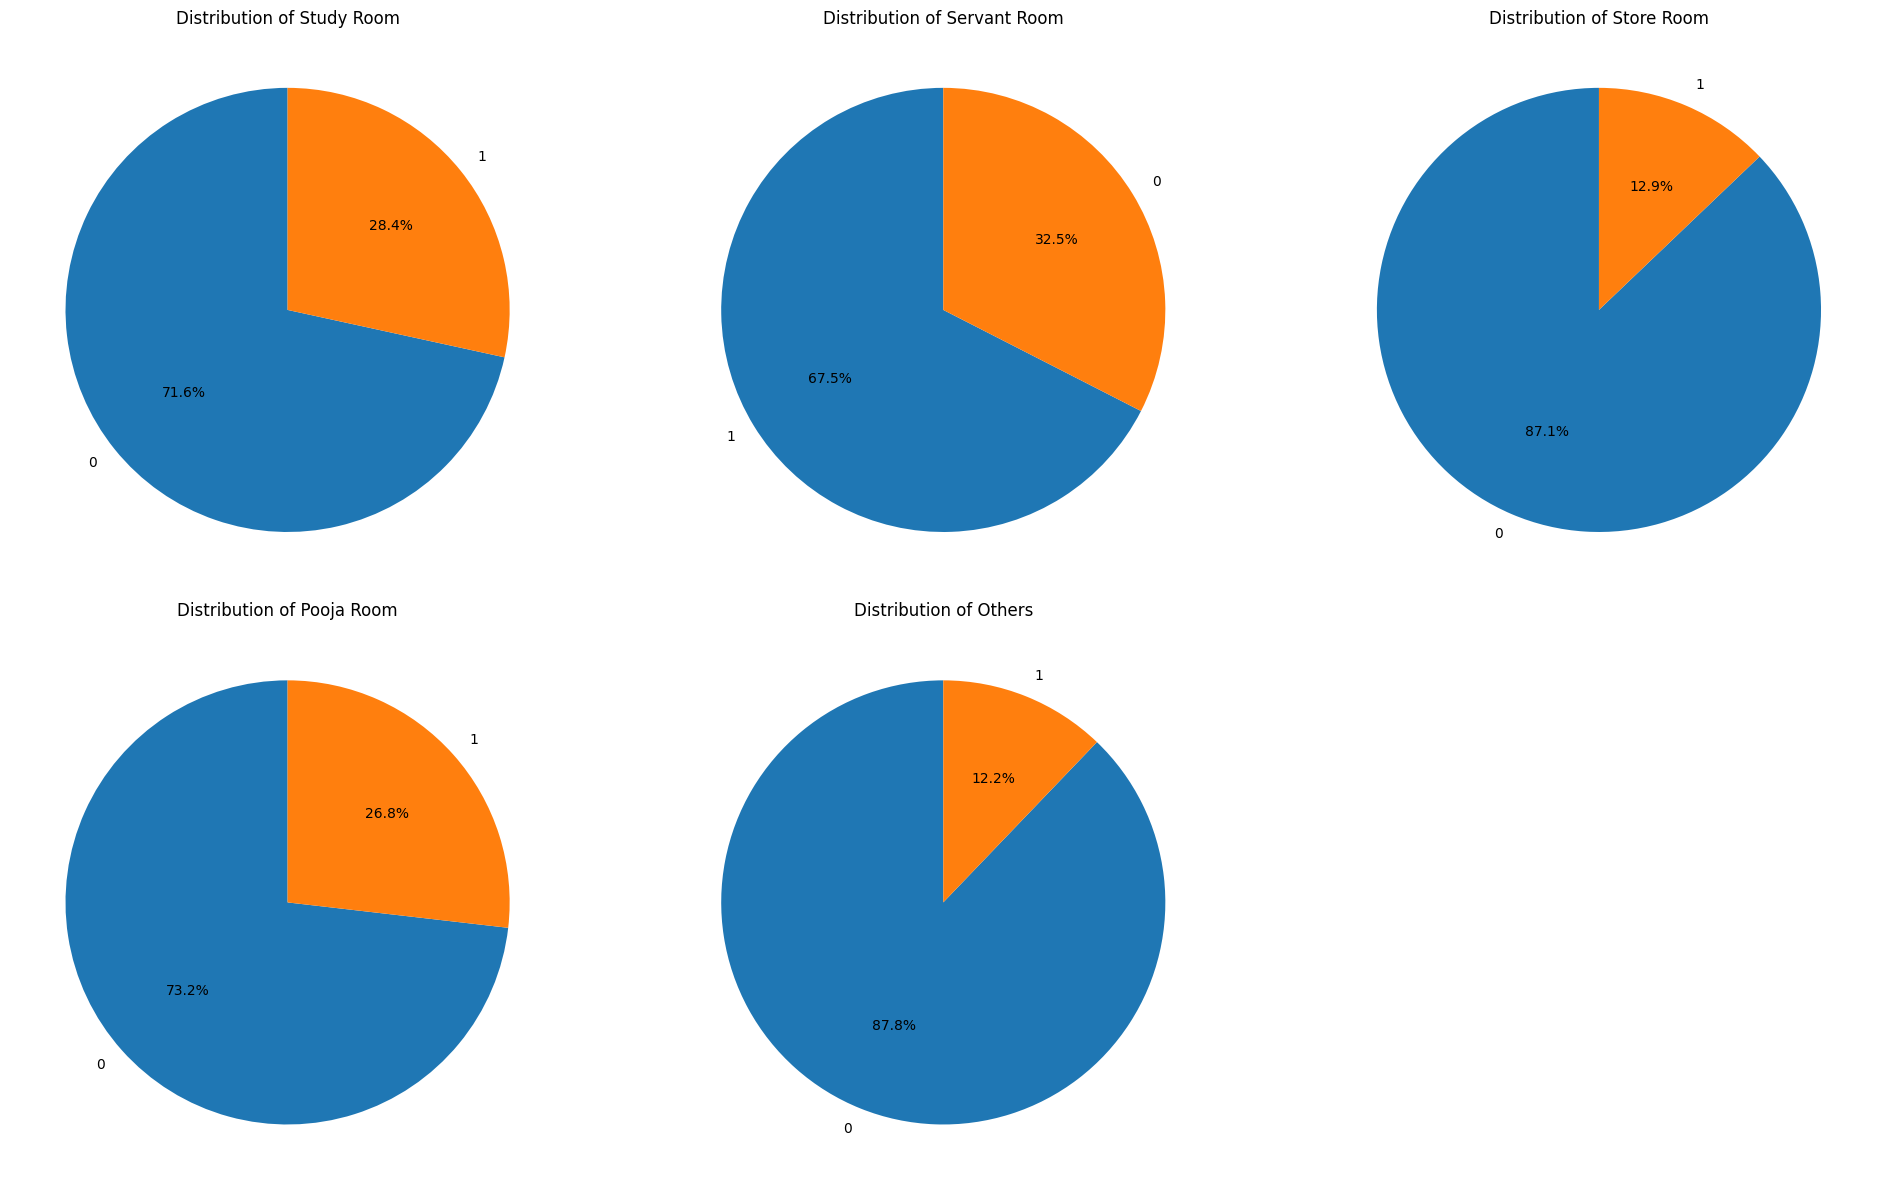

In [ ]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# furnishing_type

In [ ]:
df['furnishing_type'].isnull().sum()

np.int64(0)

In [ ]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
Semi-Furnished,1064
Unknown,337
Furnished,161


<Axes: ylabel='count'>

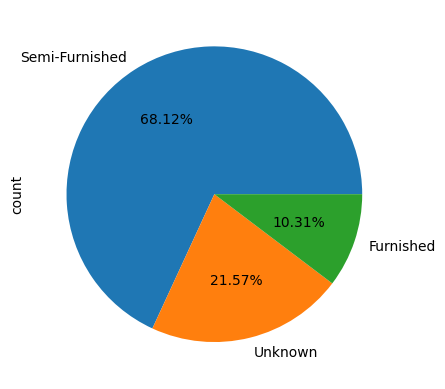

In [ ]:
df['furnishing_type'].value_counts().plot(kind='pie', autopct='%0.2f%%')

# luxury_score

In [ ]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [ ]:
df['luxury_score'].describe()

,luxury_score
count,1562.000000
mean,7.650448
std,8.839995
min,0.000000
25%,0.000000
50%,4.000000
75%,13.000000
max,45.000000


<Axes: xlabel='luxury_score', ylabel='Count'>

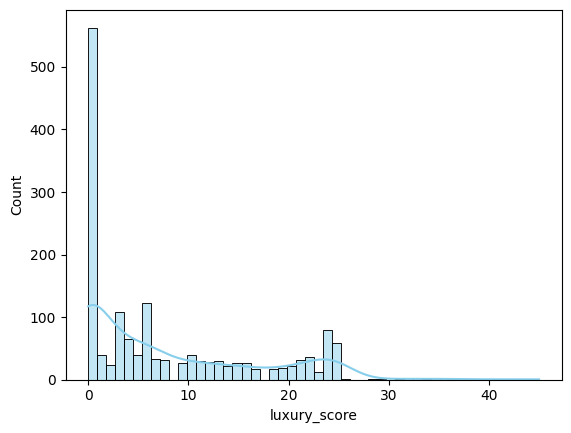

In [ ]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

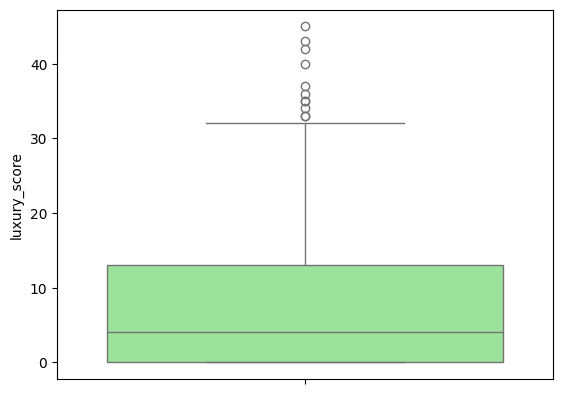

In [ ]:
sns.boxplot(df['luxury_score'], color='lightgreen')

In [ ]:
df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,...,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,dlf the magnolias,Sector 42,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up...,4,4,3+,14.0,...,5400.0,1,1,0,1,1,Furnished,1,28.454042,77.098740
1,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8.0,...,NaN,1,1,0,1,1,Unknown,5,28.508181,76.986806
2,experion windchants,Sector 112,6.25,16609.0,3763,Super Built-up area 3763(349.59 sq.m.)Built-up...,3,5,3,6.0,...,NaN,0,1,0,0,0,Semi-Furnished,0,28.518719,77.014458
3,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet a...,3,3,3,11.0,...,1141.0,0,1,0,0,0,Unknown,0,28.359337,76.969227
4,dlf new town heights 1,Sector 90,2.85,10451.0,2727,Super Built-up area 2727(253.35 sq.m.)Built-up...,4,4,3+,4.0,...,2721.0,0,1,0,1,0,Semi-Furnished,21,28.403442,76.930775
